# **Pokémon Clustering**

![Psyduck](https://images.ladbible.com/resize?type=webp&quality=70&width=3840&fit=contain&gravity=auto&url=https://images.ladbiblegroup.com/v3/assets/bltbc1876152fcd9f07/bltd8e2ea464ca2a445/6891cbc95090c7918d7fad44/pokemon.png)

## **1. Imports and data preparation**

In [336]:
import pandas as pd
import os
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [337]:
d = pd.read_csv("/content/data_clean.csv")

print(d.head())

   gen english_name  percent_male  percent_female  height_m  weight_kg  \
0  1.0    Bulbasaur         88.14           11.86       0.7        6.9   
1  1.0      Ivysaur         88.14           11.86       1.0       13.0   
2  1.0     Venusaur         88.14           11.86       2.0      100.0   
3  1.0   Charmander         88.14           11.86       0.6        8.5   
4  1.0   Charmeleon         88.14           11.86       1.1       19.0   

   capture_rate  base_egg_steps    hp  attack  ...  against_fairy  \
0          45.0          5120.0  45.0    49.0  ...            0.5   
1          45.0          5120.0  60.0    62.0  ...            0.5   
2          45.0          5120.0  80.0    82.0  ...            0.5   
3          45.0          5120.0  39.0    52.0  ...            0.5   
4          45.0          5120.0  58.0    64.0  ...            0.5   

   votes_first  votes_top_6  num_abilities  evo_length  has_mega_evolution  \
0         57.0        147.0            2.0         5.0        

### **1.1 Data cleaning and scaling**
Data cleaning was performed to remove irrelevant features and address missing values. Additionally, we applied feature scaling to normalize the data. This step is mandatory for distance-based algorithms like K-Means; without it, variables with larger magnitudes would dominate the distance calculations, leading to biased clusters.

In [338]:
#Scale data for clustering and remove unlogical columns
scaler = StandardScaler()

against_columns = [col for col in d.columns if col.startswith('against_')]

# List of other columns to drop
other_columns_to_drop = [
    'gen', 'english_name', 'votes_first', 'votes_top_6', 'num_abilities', 'evo_length', 'has_mega_evolution', 'has_gigantamax',
    'rarity', 'class_primary', 'class_secondary'
]

# Combine all columns to drop
columns_to_drop_final = against_columns + other_columns_to_drop

d_simple = d.drop(columns=columns_to_drop_final, errors='ignore')

d_scaled_np = scaler.fit_transform(d_simple)
d_scaled = pd.DataFrame(d_scaled_np, columns=d_simple.columns)

display(d_scaled.head()) #scale logical variables

,percent_male,percent_female,height_m,weight_kg,capture_rate,base_egg_steps,hp,attack,defense,sp_attack,sp_defense,speed
0,1.533099,-1.067708,-0.409473,-0.495198,-0.656788,-0.290495,-0.945176,-0.956826,-0.802617,-0.170282,-0.195466,-0.772656
1,1.533099,-1.067708,-0.169094,-0.444898,-0.656788,-0.290495,-0.381505,-0.520603,-0.324819,0.335820,0.367196,-0.250320
2,1.533099,-1.067708,0.632167,0.272495,-0.656788,-0.290495,0.370056,0.150509,0.357748,1.010623,1.117412,0.446128
3,1.533099,-1.067708,-0.489599,-0.482005,-0.656788,-0.290495,-1.170644,-0.856159,-1.007387,-0.338983,-0.758128,-0.076208
4,1.533099,-1.067708,-0.088968,-0.395423,-0.656788,-0.290495,-0.456661,-0.453492,-0.495461,0.335820,-0.195466,0.446128


In [339]:
data_clean_normal_pre_scale = d[d['rarity'] == 0].copy()
d_scaled_normal_np = scaler.transform(data_clean_normal_pre_scale[d_scaled.columns])
data_clean_normal = pd.DataFrame(d_scaled_normal_np, columns=d_scaled.columns)

data_clean_normal.to_csv("/content/data_clean_normal.csv")

display(data_clean_normal.head())

,percent_male,percent_female,height_m,weight_kg,capture_rate,base_egg_steps,hp,attack,defense,sp_attack,sp_defense,speed
0,1.533099,-1.067708,-0.409473,-0.495198,-0.656788,-0.290495,-0.945176,-0.956826,-0.802617,-0.170282,-0.195466,-0.772656
1,1.533099,-1.067708,-0.169094,-0.444898,-0.656788,-0.290495,-0.381505,-0.520603,-0.324819,0.335820,0.367196,-0.250320
2,1.533099,-1.067708,0.632167,0.272495,-0.656788,-0.290495,0.370056,0.150509,0.357748,1.010623,1.117412,0.446128
3,1.533099,-1.067708,-0.489599,-0.482005,-0.656788,-0.290495,-1.170644,-0.856159,-1.007387,-0.338983,-0.758128,-0.076208
4,1.533099,-1.067708,-0.088968,-0.395423,-0.656788,-0.290495,-0.456661,-0.453492,-0.495461,0.335820,-0.195466,0.446128


### **1.2 Sub-legendary/Legendary/Mythical**
A strong factor in Generation 7's ranking appears to be the sheer number of Legendary and Mythical Pokémon, which naturally raises the generation's average stats

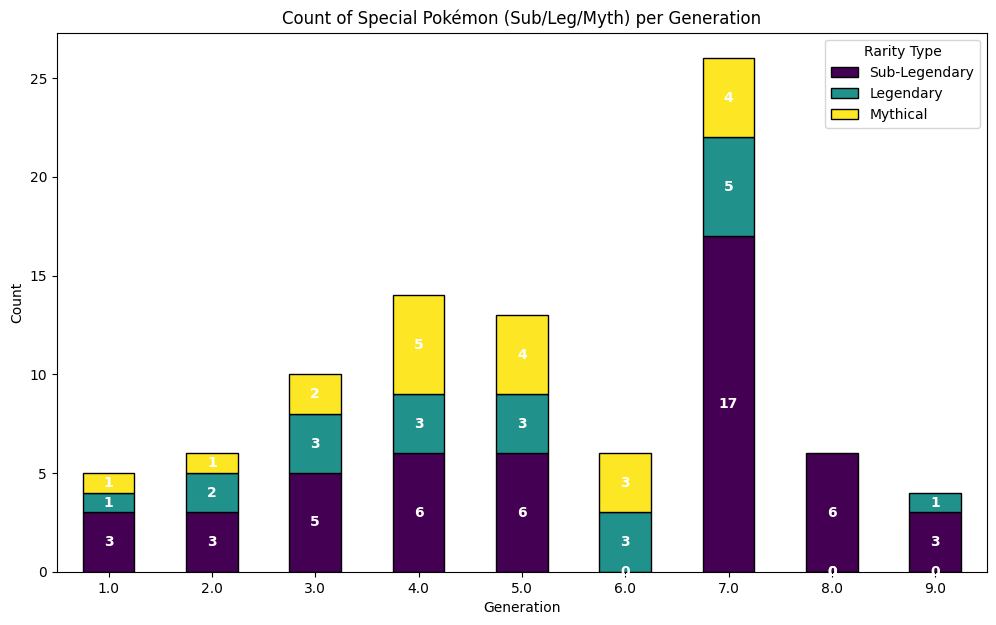


Exact counts of special Pokémon per generation:


rarity_label,Sub-Legendary,Legendary,Mythical
gen,,,
1.0,3,1,1
2.0,3,2,1
3.0,5,3,2
4.0,6,3,5
5.0,6,3,4
6.0,0,3,3
7.0,17,5,4
8.0,6,0,0
9.0,3,1,0


In [340]:
# 1. Filter only special Pokémon (exclude normal ones)
# Rarity > 0 implies Sub-Legendary, Legendary, or Mythical
special_pokemon = d[d['rarity'] > 0].copy()

# 2. Map numeric rarity to text labels for better plotting
rarity_map = {1.0: 'Sub-Legendary', 2.0: 'Legendary', 3.0: 'Mythical'}
special_pokemon['rarity_label'] = special_pokemon['rarity'].map(rarity_map)

# 3. Prepare data: Count occurrences of each rarity type per generation
# unstack() turns the rarity labels into columns
counts_per_gen = special_pokemon.groupby(['gen', 'rarity_label']).size().unstack(fill_value=0)

# 4. Reorder columns logically (Sub -> Leg -> Myth)
desired_order = ['Sub-Legendary', 'Legendary', 'Mythical']
# Filter desired_order to include only columns that actually exist in the data
existing_order = [col for col in desired_order if col in counts_per_gen.columns]
counts_per_gen = counts_per_gen[existing_order]

# 5. Plot Stacked Bar Chart
# 'stacked=True' stacks the bars on top of each other
ax = counts_per_gen.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis', edgecolor='black')

plt.title('Count of Special Pokémon (Sub/Leg/Myth) per Generation')
plt.xlabel('Generation')
plt.ylabel('Count')
plt.xticks(rotation=0) # Keep generation numbers horizontal
plt.legend(title='Rarity Type')

# Optional: Add value labels on the bars
for c in ax.containers:
    ax.bar_label(c, label_type='center', color='white', weight='bold')

plt.show()

# --- Print the exact numbers table ---
print("\nExact counts of special Pokémon per generation:")
display(counts_per_gen)

## **2. K-Means**
We employed the K-Means algorithm for this study using the default **k-means++** initialization. Unlike standard random initialization, **k-means++** selects initial cluster centers that are *far apart*, which ensures faster convergence and more reliable clustering results.

In [341]:
k = 9

kmeans = KMeans(n_clusters=k, n_init=10000)

d_with_clusters = d.copy()

kmeans_res = kmeans.fit_predict(d_scaled)
d_with_clusters["cluster"] = kmeans_res

### **2.1 Cluster Ordering**
To avoid confusion, we ordered the clusters from weakest to strongest based on their average statistics.

In [342]:
stat_cols = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']

cluster_stats = d_with_clusters.groupby('cluster')[stat_cols].mean()

cluster_strength = cluster_stats.sum(axis=1).sort_values()

mapping = {old_label: new_label for new_label, old_label in enumerate(cluster_strength.index)}

print("Cluster Mapping (Old Label -> New Ordered Label):")
print(mapping)

d_with_clusters['cluster'] = d_with_clusters['cluster'].map(mapping)

kmeans_res = d_with_clusters['cluster'].values

d_with_clusters.to_csv("/content/data_clean_clusters.csv")
print("Saved sorted clusters to /content/data_clean_clusters.csv")

ordered_summary = d_with_clusters.groupby('cluster')[stat_cols].mean()
ordered_summary['total_avg_stats'] = ordered_summary.sum(axis=1)
display(ordered_summary)

Cluster Mapping (Old Label -> New Ordered Label):
{5: 0, 3: 1, 1: 2, 4: 3, 0: 4, 7: 5, 6: 6, 8: 7, 2: 8}
Saved sorted clusters to /content/data_clean_clusters.csv


,hp,attack,defense,sp_attack,sp_defense,speed,total_avg_stats
cluster,,,,,,,
0,49.049342,51.822368,50.003289,45.368421,47.496711,48.667763,292.407895
1,64.859259,77.288889,65.681481,74.192593,69.570370,71.370370,422.962963
2,71.333333,88.127273,66.533333,73.515152,66.230303,93.212121,458.951515
3,78.240310,65.100775,80.790698,86.976744,95.666667,55.201550,461.976744
4,90.065217,109.239130,100.833333,68.927536,76.079710,60.101449,505.246377
5,114.000000,81.000000,123.000000,77.000000,63.000000,65.000000,523.000000
6,77.890625,87.828125,97.406250,90.734375,96.093750,84.671875,534.625000
7,116.625000,113.812500,115.750000,82.062500,89.500000,56.687500,574.437500
8,94.941176,107.735294,90.794118,111.073529,94.117647,101.838235,600.500000


### **2.2 Distribution of generations per Cluster**

cluster
0    304
1    135
2    165
3    129
4    138
5      5
6     64
7     16
8     68
dtype: int64


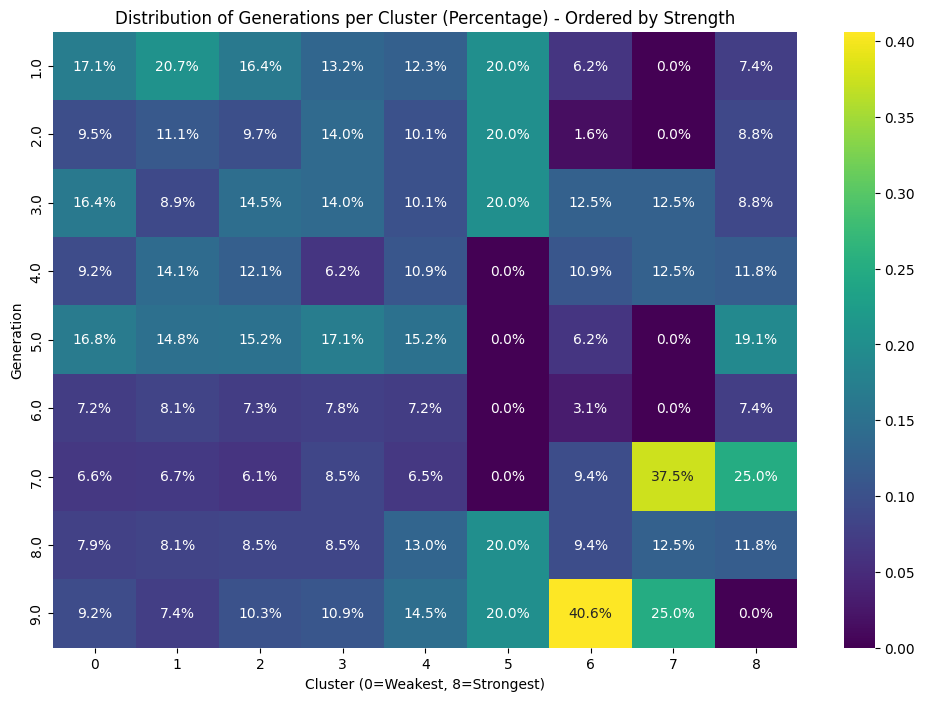

In [343]:
cluster_counts_per_gen = d_with_clusters.groupby(['gen', 'cluster']).size().reset_index(name='count')

print(d_with_clusters.groupby([ 'cluster']).size())

heatmap_data = cluster_counts_per_gen.pivot_table(
    index='gen',
    columns='cluster',
    values='count'
).fillna(0)

heatmap_data_percent = heatmap_data.apply(lambda x: x / x.sum(), axis=0)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_percent, annot=True, fmt='.1%', cmap='viridis')
plt.title('Distribution of Generations per Cluster (Percentage) - Ordered by Strength')
plt.xlabel('Cluster (0=Weakest, 8=Strongest)')
plt.ylabel('Generation')
plt.show()

Number of Pokémon in each cluster (sorted by strength 0 -> 8):
cluster
0    304
1    135
2    165
3    129
4    138
5      5
6     64
7     16
8     68
dtype: int64


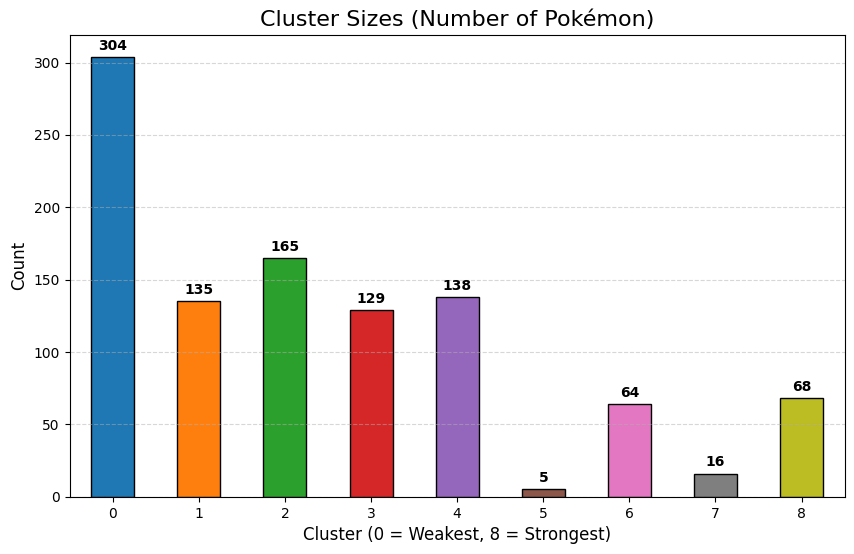

In [344]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the size of each cluster
cluster_sizes = d_with_clusters.groupby(['cluster']).size()

print("Number of Pokémon in each cluster (sorted by strength 0 -> 8):")
print(cluster_sizes)

plt.figure(figsize=(10, 6))

colors = [color_strength_mapping[i] for i in sorted(cluster_sizes.index)]

cluster_sizes.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Cluster Sizes (Number of Pokémon)', fontsize=16)
plt.xlabel('Cluster (0 = Weakest, 8 = Strongest)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for index, value in enumerate(cluster_sizes):
    plt.text(index, value + 5, str(value), ha='center', fontweight='bold')

plt.show()

### **2.3 Clustering of Sub-legendary/Legendary/Mythical Pokémon**

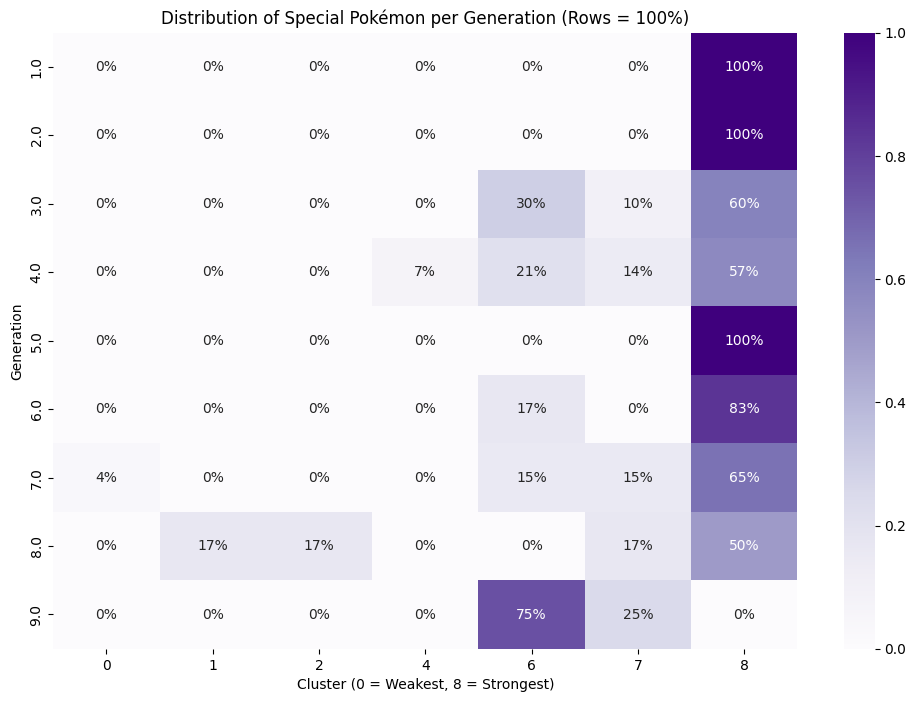


Total count of special Pokémon per generation (Base for 100%):
gen
1.0     5
2.0     6
3.0    10
4.0    14
5.0    13
6.0     6
7.0    26
8.0     6
9.0     4
dtype: int64


In [345]:
# 1. Filter only special Pokémon (exclude normal ones)
# Rarity > 0 implies Sub-Legendary, Legendary, or Mythical
special_pokemon = d_with_clusters[d_with_clusters['rarity'] > 0].copy()

# 2. Create a count table: How many special Pokémon are in each Gen and Cluster?
heatmap_counts = special_pokemon.pivot_table(
    index='gen',
    columns='cluster',
    aggfunc='size',  # Count occurrences
    fill_value=0
)

# 3. Normalize rows so that the sum in each generation is 100% (1.0)
# axis=0 ensures we divide each row by its sum (row-wise normalization)
heatmap_percent_row = heatmap_counts.div(heatmap_counts.sum(axis=1), axis=0)

# 4. Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_percent_row,
    annot=True,
    fmt='.0%',      # Show percentages without decimals
    cmap='Purples', # Purple color fits "rarity/legends" theme
    vmin=0, vmax=1  # Fix scale from 0% to 100%
)

plt.title('Distribution of Special Pokémon per Generation (Rows = 100%)')
plt.xlabel('Cluster (0 = Weakest, 8 = Strongest)')
plt.ylabel('Generation')
plt.show()

print("\nTotal count of special Pokémon per generation (Base for 100%):")
print(heatmap_counts.sum(axis=1))

### **2.4 K-means with optimal k**
Perform the elbow method.

In [ ]:

wcss = []

for i in range(1, 16): # Looping from K=1 to K=15
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(d_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the results onto a line graph to observe the elbow
plt.figure(figsize=(10, 6))
plt.plot(range(1, 16), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [ ]:
optimal_k = 4 # Based on visual inspection of the elbow plot

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=0)

new_kmeans_predictions = kmeans.fit_predict(d_scaled)

d_with_clusters = d.copy()
d_with_clusters["cluster"] = new_kmeans_predictions

kmeans_res = new_kmeans_predictions

print(f"KMeans clustering re-run with optimal K = {optimal_k}")
print("First 5 rows of d_with_clusters with new cluster assignments:")
print(d_with_clusters.head())


In [ ]:

stat_cols = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']

cluster_stats = d_with_clusters.groupby('cluster')[stat_cols].mean()

cluster_strength = cluster_stats.sum(axis=1).sort_values()

mapping = {old_label: new_label for new_label, old_label in enumerate(cluster_strength.index)}

print("Cluster Mapping (Old Label -> New Ordered Label):")
print(mapping)

d_with_clusters['cluster'] = d_with_clusters['cluster'].map(mapping)

kmeans_res = d_with_clusters['cluster'].values

ordered_summary = d_with_clusters.groupby('cluster')[stat_cols].mean()
ordered_summary['total_avg_stats'] = ordered_summary.sum(axis=1)
display(ordered_summary)


In [ ]:

cluster_counts_per_gen = d_with_clusters.groupby(['gen', 'cluster']).size().reset_index(name='count')

heatmap_data = cluster_counts_per_gen.pivot_table(
    index='gen',
    columns='cluster',
    values='count'
).fillna(0)

heatmap_data_percent = heatmap_data.apply(lambda x: x / x.sum(), axis=0)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_percent, annot=True, fmt='.1%', cmap='viridis')
plt.title('Distribution of Generations per Cluster (Percentage) - Ordered by Strength')
plt.xlabel(f'Cluster (0=Weakest, {optimal_k-1}=Strongest)')
plt.ylabel('Generation')
plt.show()


In [ ]:

# 1. Filter only special Pokémon (Sub-Legendary, Legendary, Mythical)
# Rarity > 0 (where 0 = Normal)
special_pokemon = d_with_clusters[d_with_clusters['rarity'] > 0]

# 2. Create a count table: How many special Pokémon are in each Gen and Cluster?
heatmap_counts = special_pokemon.pivot_table(
    index='gen',
    columns='cluster',
    aggfunc='size',  # Count occurrences
    fill_value=0
)

# 3. Normalize rows so that the sum in each generation is 100% (1.0)
# axis=0 ensures we divide each row by its sum (row-wise normalization)
heatmap_percent_row = heatmap_counts.div(heatmap_counts.sum(axis=1), axis=0)

# 4. Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_percent_row,
    annot=True,
    fmt='.0%',      # Show percentages without decimals
    cmap='Purples', # Purple color fits "rarity/legends" theme
    vmin=0, vmax=1  # Fix scale from 0% to 100%
)

plt.title('Distribution of Special Pokémon per Generation (Rows = 100%)')
plt.xlabel(f'Cluster (0 = Weakest, {optimal_k-1} = Strongest)')
plt.ylabel('Generation')
plt.show()

print("\nTotal count of special Pokémon per generation (Base for 100%):")
print(heatmap_counts.sum(axis=1))

## **3. EM GMM**

### **3.1 EM GMM with k=9**
Run Expectation-Maximization Gaussian Mixture Model (EM GMM) on the `d_scaled` dataset with k=9 clusters and store the cluster assignments in `d_with_clusters`.

In [ ]:

from sklearn.mixture import GaussianMixture
# Instantiate GaussianMixture model with k=9 clusters and a random_state for reproducibility
gmm = GaussianMixture(n_components=9, random_state=42)

# Fit the GMM model to the d_scaled DataFrame
gmm.fit(d_scaled)

# Predict the cluster assignments for each data point in d_scaled
gmm_predictions = gmm.predict(d_scaled)

# Add the cluster assignments to a copy of the original DataFrame for further analysis
d_with_clusters_gmm_9 = d.copy()
d_with_clusters_gmm_9['cluster'] = gmm_predictions


In [ ]:
stat_cols = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']

cluster_stats = d_with_clusters_gmm_9.groupby('cluster')[stat_cols].mean()

cluster_strength = cluster_stats.sum(axis=1).sort_values()

mapping = {old_label: new_label for new_label, old_label in enumerate(cluster_strength.index)}

print("Cluster Mapping (Old Label -> New Ordered Label):")
print(mapping)

d_with_clusters_gmm_9['cluster'] = d_with_clusters_gmm_9['cluster'].map(mapping)

gmm_res = d_with_clusters_gmm_9['cluster'].values

d_with_clusters_gmm_9.to_csv("/content/data_clean_clusters_gmm.csv")

ordered_summary = d_with_clusters_gmm_9.groupby('cluster')[stat_cols].mean()
ordered_summary['total_avg_stats'] = ordered_summary.sum(axis=1)
display(ordered_summary)


In [ ]:
cluster_counts_per_gen = d_with_clusters_gmm_9.groupby(['gen', 'cluster']).size().reset_index(name='count')

print(d_with_clusters_gmm_9.groupby([ 'cluster']).size())

heatmap_data = cluster_counts_per_gen.pivot_table(
    index='gen',
    columns='cluster',
    values='count'
).fillna(0)

heatmap_data_percent = heatmap_data.apply(lambda x: x / x.sum(), axis=0)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_percent, annot=True, fmt='.1%', cmap='viridis')
plt.title('Distribution of Generations per Cluster (Percentage) - Ordered by Strength')
plt.xlabel('Cluster (0=Weakest, 8=Strongest)')
plt.ylabel('Generation')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the size of each cluster
cluster_sizes = d_with_clusters_gmm_9.groupby(['cluster']).size()

print("Number of Pokémon in each cluster (sorted by strength 0 -> 8):")
print(cluster_sizes)

plt.figure(figsize=(10, 6))

colors = [color_strength_mapping[i] for i in sorted(cluster_sizes.index)]

cluster_sizes.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Cluster Sizes (Number of Pokémon)', fontsize=16)
plt.xlabel('Cluster (0 = Weakest, 8 = Strongest)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for index, value in enumerate(cluster_sizes):
    plt.text(index, value + 5, str(value), ha='center', fontweight='bold')

plt.show()
plot_special_pokemon_heatmap(d_with_clusters_gmm_9, cluster_col='cluster', title_suffix='(EM GMM)')

### **EM GMM for optimal k**
Generate a plot showing the BIC and AIC scores against the number of clusters (K). This plot will help determine the optimal K, which is typically the value that minimizes these scores.

In [ ]:

import matplotlib.pyplot as plt
K_range = range(2, 17) # Changed from range(2, 16) to range(2, 17)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot BIC scores
color = 'tab:red'
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('BIC Score', color=color)
ax1.plot(K_range, bic_scores, marker='o', color=color, label='BIC Score')
ax1.tick_params(axis='y', labelcolor=color)

# Create a second y-axis for AIC scores
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('AIC Score', color=color)
ax2.plot(K_range, aic_scores, marker='s', linestyle='--', color=color, label='AIC Score')
ax2.tick_params(axis='y', labelcolor=color)

# Add title and legend
fig.tight_layout() # otherwise the right y-label is slightly clipped
plt.title('BIC and AIC Scores for GMM')

# Combine legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right')

plt.show()



Based on the BIC and AIC plots, select an optimal K. Re-run the GaussianMixture model on the `d_scaled` dataset using this optimal K and update the `d_with_clusters_gmm_optimal` DataFrame with the new cluster assignments.
Based on the BIC and AIC plots, I will select K=13 as the optimal number of clusters as instructed. Then, we will instantiate a GaussianMixture model with this optimal K, fit it to the `d_scaled` dataset, predict the cluster assignments, and store these in a new DataFrame `d_with_clusters_gmm_optimal`.


In [ ]:


optimal_k_gmm = 13 # Based on visual inspection of BIC and AIC plots

gmm_optimal = GaussianMixture(n_components=optimal_k_gmm, random_state=42)

gmm_optimal.fit(d_scaled)

gmm_optimal_predictions = gmm_optimal.predict(d_scaled)

d_with_clusters_gmm_optimal = d.copy()
d_with_clusters_gmm_optimal['cluster'] = gmm_optimal_predictions

print(f"EM GMM clustering re-run with optimal K = {optimal_k_gmm}")
print("First 5 rows of d_with_clusters_gmm_optimal with new cluster assignments:")
print(d_with_clusters_gmm_optimal.head())


In [ ]:


stat_cols = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']

cluster_stats = d_with_clusters_gmm_optimal.groupby('cluster')[stat_cols].mean()

cluster_strength = cluster_stats.sum(axis=1).sort_values()

mapping = {old_label: new_label for new_label, old_label in enumerate(cluster_strength.index)}

print("Cluster Mapping (Old Label -> New Ordered Label):")
print(mapping)

d_with_clusters_gmm_optimal['cluster'] = d_with_clusters_gmm_optimal['cluster'].map(mapping)

ordered_summary = d_with_clusters_gmm_optimal.groupby('cluster')[stat_cols].mean()
ordered_summary['total_avg_stats'] = ordered_summary.sum(axis=1)
display(ordered_summary)


In [ ]:


cluster_counts_per_gen = d_with_clusters_gmm_optimal.groupby(['gen', 'cluster']).size().reset_index(name='count')

heatmap_data = cluster_counts_per_gen.pivot_table(
    index='gen',
    columns='cluster',
    values='count'
).fillna(0)

heatmap_data_percent = heatmap_data.apply(lambda x: x / x.sum(), axis=0)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_percent, annot=True, fmt='.1%', cmap='viridis')
plt.title('Distribution of Generations per GMM Cluster (Percentage) - Ordered by Strength')
plt.xlabel(f'Cluster (0=Weakest, {optimal_k_gmm-1}=Strongest)')
plt.ylabel('Generation')
plt.show()


In [ ]:

plot_special_pokemon_heatmap(d_with_clusters_gmm_optimal, cluster_col='cluster', title_suffix='(EM GMM Optimal K)')

## **4. Hiearchical Clustering**
*Why might we opt for this method ?*

Unlike **K-Means**, this algorithm is deterministic and creates visualizing trees called **dendrograms** (often quite satisfying to look at).

In [366]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

### **4.1 Linkage Matrix**
The linkage matrix is the fundamental data structure produced by the hierarchical clustering algorithm. It contains the complete history of how clusters were merged, step by step

In the plot

In [367]:
linked = linkage(d_scaled, method='ward')

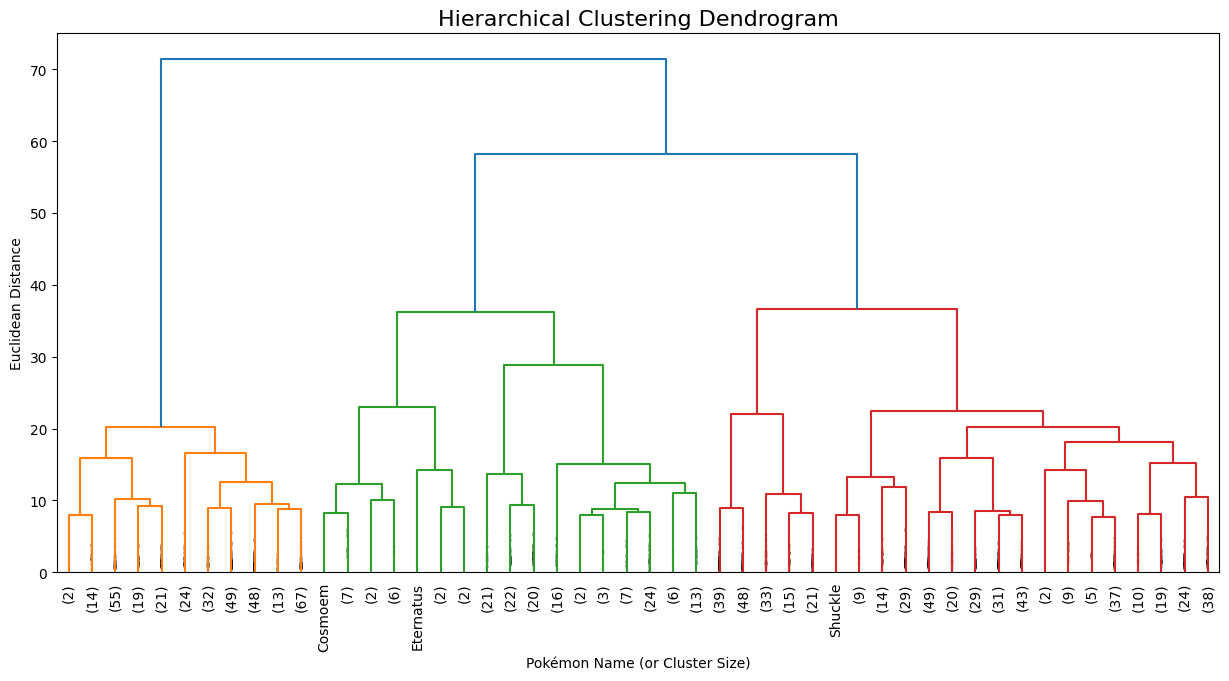

In [368]:
pokemon_names = d['english_name'].values

plt.figure(figsize=(15, 7))
plt.title('Hierarchical Clustering Dendrogram', fontsize=16)
plt.xlabel('Pokémon Name (or Cluster Size)')
plt.ylabel('Euclidean Distance')

dendrogram(
    linked,
    truncate_mode='lastp',
    p=50,                   # Show top 50 branches
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True,
    labels=pokemon_names
)

plt.show()

### **4.2 Application of the model**

In [369]:
# Configuration
n_clusters_hc = 9 # feel free to change this
hc_model = AgglomerativeClustering(n_clusters=n_clusters_hc, linkage='ward')
hc_labels = hc_model.fit_predict(d_scaled)

d_hc = d.copy()
d_hc['cluster_hc'] = hc_labels

In [370]:
# Fix the cluster ordering by power
stat_cols = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']
hc_summary = d_hc.groupby('cluster_hc')[stat_cols].mean()
hc_summary['total_avg'] = hc_summary.sum(axis=1)
hc_summary = hc_summary.sort_values('total_avg')

print("\nAverage Stats for Hierarchical Clusters (Sorted by Strength):")
display(hc_summary)


Average Stats for Hierarchical Clusters (Sorted by Strength):


,hp,attack,defense,sp_attack,sp_defense,speed,total_avg
cluster_hc,,,,,,,
1,51.255814,55.098837,51.546512,49.340116,49.898256,51.415698,308.555233
8,55.402299,65.057471,57.850575,60.804598,55.954023,58.712644,353.781609
3,68.471698,88.603774,125.660377,51.113208,82.132075,46.471698,462.452830
0,82.471519,87.762658,76.512658,80.835443,79.639241,76.044304,483.265823
7,79.985507,99.333333,80.753623,87.840580,85.275362,84.043478,517.231884
2,114.000000,81.000000,123.000000,77.000000,63.000000,65.000000,523.000000
5,80.619048,90.063492,94.571429,91.095238,92.174603,84.904762,533.428571
6,121.312500,115.500000,113.187500,79.750000,87.062500,57.000000,573.812500
4,92.746479,106.352113,94.352113,109.169014,97.816901,100.394366,600.830986


In [371]:
def get_member_indices(node_id, n_samples, linkage_matrix):
    if node_id < n_samples:
        return [node_id]
    else:
        left_child = int(linkage_matrix[node_id - n_samples, 0])
        right_child = int(linkage_matrix[node_id - n_samples, 1])
        return get_member_indices(left_child, n_samples, linkage_matrix) + \
               get_member_indices(right_child, n_samples, linkage_matrix)

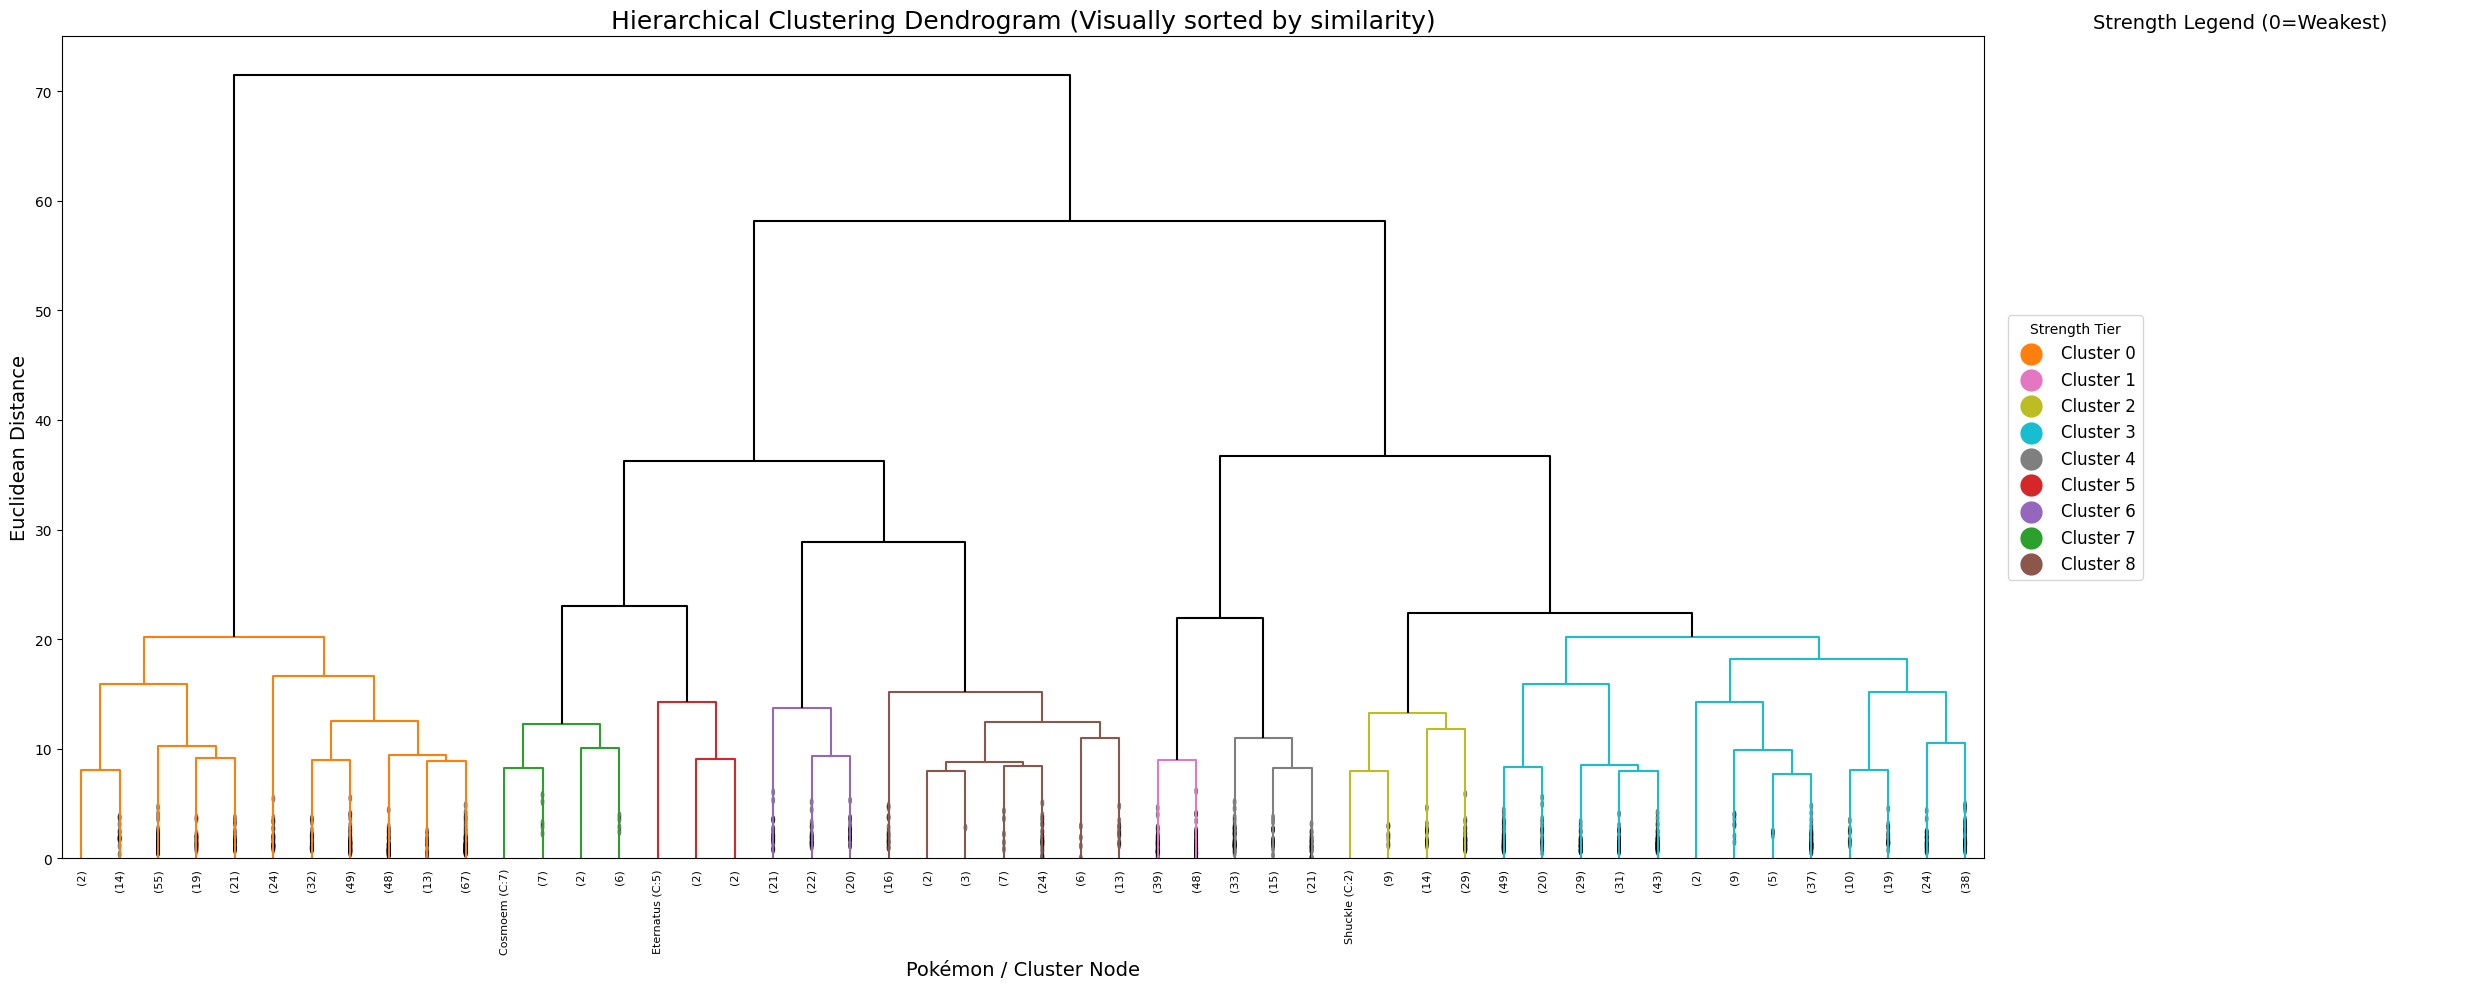

In [372]:
stat_cols = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']
hc_summary = d_hc.groupby('cluster_hc')[stat_cols].mean()
hc_summary['total_avg'] = hc_summary.sum(axis=1)
hc_summary = hc_summary.sort_values('total_avg')
hc_mapping = {old: new for new, old in enumerate(hc_summary.index)}
d_hc['cluster_hc_ordered'] = d_hc['cluster_hc'].map(hc_mapping)

dendrogram_labels = []
for index, row in d_hc.iterrows():
    label = f"{row['english_name']} (C:{int(row['cluster_hc_ordered'])})"
    dendrogram_labels.append(label)

n_clusters_to_color = d_hc['cluster_hc_ordered'].nunique()
N = len(d_scaled)

sorted_distances = np.sort(linked[:, 2])
if (N - n_clusters_to_color) >= 0 and (N - n_clusters_to_color) < len(sorted_distances):
    color_threshold_value = sorted_distances[N - n_clusters_to_color]
else:
    color_threshold_value = sorted_distances[0] if len(sorted_distances) > 0 else 0.0

fig, axes = plt.subplots(1, 2, figsize=(25, 10), gridspec_kw={'width_ratios': [4, 1]})

axes[0].set_title(f'Hierarchical Clustering Dendrogram (Visually sorted by similarity)', fontsize=18)
axes[0].set_xlabel('Pokémon / Cluster Node', fontsize=14)
axes[0].set_ylabel('Euclidean Distance', fontsize=14)

R = dendrogram(
    linked,
    labels=dendrogram_labels,
    leaf_rotation=90.,
    leaf_font_size=8.,
    show_contracted=True,
    truncate_mode='lastp',
    p=50,
    color_threshold=color_threshold_value,
    above_threshold_color='black',
    ax=axes[0]
)
axes[0].tick_params(axis='x', rotation=90)

leaf_colors = R['leaves_color_list']
leaf_nodes = R['leaves']
cluster_color_map = {}

for node_id, color in zip(leaf_nodes, leaf_colors):
    if color == 'black': continue

    member_indices = get_member_indices(node_id, N, linked)

    current_clusters = d_hc.iloc[member_indices]['cluster_hc_ordered']
    if not current_clusters.empty:
        dominant_cluster = current_clusters.mode()[0]
        cluster_color_map[dominant_cluster] = color

axes[1].set_title('Strength Legend (0=Weakest)', fontsize=14)
axes[1].axis('off')

for cluster_id in sorted(cluster_color_map.keys()):
    color = cluster_color_map[cluster_id]
    axes[1].scatter([], [], color=color, s=100, label=f'Cluster {int(cluster_id)}')

axes[1].legend(loc='center left', bbox_to_anchor=(0, 0.5), fontsize=12, title="Strength Tier", markerscale=1.5)

plt.tight_layout()
plt.show()

### **4.4 Sorting**

In [374]:
original_cluster_sizes = d_hc['cluster_hc'].value_counts().sort_index()

print("Counts of Pokémon in Original Clusters (Before Sorting):")
print(original_cluster_sizes)

print("\nMapping: Original ID -> Sorted ID (Strength 0-8):")
print("-" * 50)
for old_id, new_id in sorted(hc_mapping.items()):
    count = original_cluster_sizes[old_id]
    print(f"Original Cluster {old_id} (Count: {count})  ==>  Sorted Cluster {new_id}")

Counts of Pokémon in Original Clusters (Before Sorting):
cluster_hc
0    316
1    344
2      5
3     53
4     71
5     63
6     16
7     69
8     87
Name: count, dtype: int64

Mapping: Original ID -> Sorted ID (Strength 0-8):
--------------------------------------------------
Original Cluster 0 (Count: 316)  ==>  Sorted Cluster 3
Original Cluster 1 (Count: 344)  ==>  Sorted Cluster 0
Original Cluster 2 (Count: 5)  ==>  Sorted Cluster 5
Original Cluster 3 (Count: 53)  ==>  Sorted Cluster 2
Original Cluster 4 (Count: 71)  ==>  Sorted Cluster 8
Original Cluster 5 (Count: 63)  ==>  Sorted Cluster 6
Original Cluster 6 (Count: 16)  ==>  Sorted Cluster 7
Original Cluster 7 (Count: 69)  ==>  Sorted Cluster 4
Original Cluster 8 (Count: 87)  ==>  Sorted Cluster 1


Number of Pokémon in each cluster (sorted by strength 0 -> 8):
cluster_hc_ordered
0    344
1     87
2     53
3    316
4     69
5      5
6     63
7     16
8     71
Name: count, dtype: int64


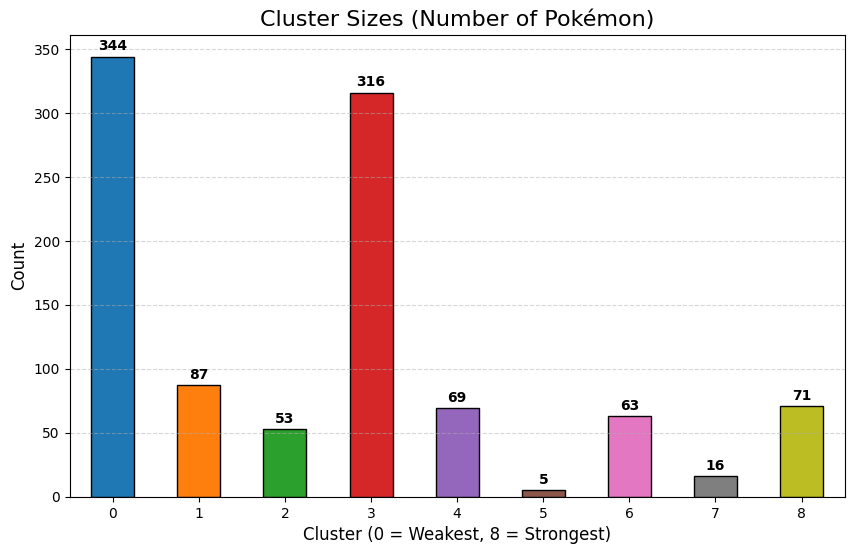

In [375]:
cluster_sizes = d_hc['cluster_hc_ordered'].value_counts().sort_index()

print("Number of Pokémon in each cluster (sorted by strength 0 -> 8):")
print(cluster_sizes)

plt.figure(figsize=(10, 6))

colors = [color_strength_mapping[i] for i in sorted(cluster_sizes.index)]

cluster_sizes.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Cluster Sizes (Number of Pokémon)', fontsize=16)
plt.xlabel('Cluster (0 = Weakest, 8 = Strongest)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for index, value in enumerate(cluster_sizes):
    plt.text(index, value + 5, str(value), ha='center', fontweight='bold')

plt.show()

### **4.4 Generation Distribution**

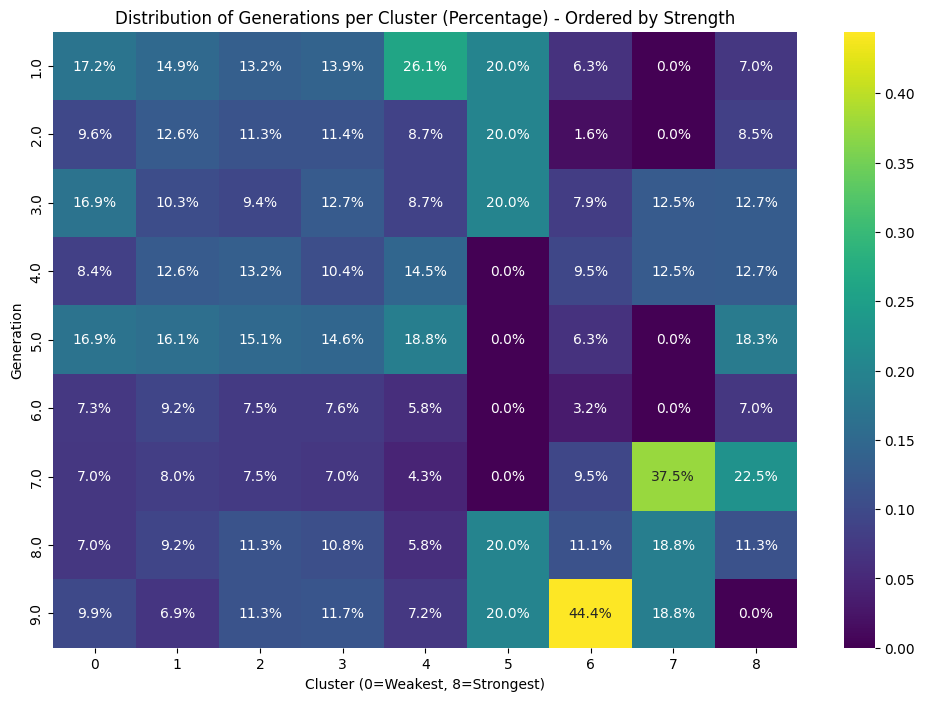

In [377]:
cluster_counts_per_gen = d_hc.groupby(['gen', 'cluster_hc_ordered']).size().reset_index(name='count')

heatmap_data = cluster_counts_per_gen.pivot_table(
    index='gen',
    columns='cluster_hc_ordered',
    values='count'
).fillna(0)

heatmap_data_percent = heatmap_data.apply(lambda x: x / x.sum(), axis=0)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_percent, annot=True, fmt='.1%', cmap='viridis')
plt.title('Distribution of Generations per Cluster (Percentage) - Ordered by Strength')
plt.xlabel('Cluster (0=Weakest, 8=Strongest)')
plt.ylabel('Generation')
plt.show()

### **4.5 Sub-legendary/Legendary/Mythical distribution**

In [378]:
def plot_special_pokemon_heatmap(df, cluster_col='cluster_hc_ordered', title_suffix=''):
    """
    Plots a heatmap of Special Pokémon distribution across generations and clusters.
    Dynamically adapts to the number of clusters in the provided column.

    Parameters:
    - df: DataFrame containing the data.
    - cluster_col: The column name with ordered cluster labels (0=Weakest).
    - title_suffix: Optional string to append to the title.
    """

    df_plot = df.copy()

    if 'rarity' not in df_plot.columns:

        df_plot['rarity'] = df_plot['legendary'].astype(int)

    special_pokemon = df_plot[df_plot['rarity'] > 0].copy()

    if special_pokemon.empty:
        print("No special Pokémon found based on 'rarity' column.")
        return

    heatmap_counts = special_pokemon.pivot_table(
        index='gen',
        columns=cluster_col,
        aggfunc='size',
        fill_value=0
    )

    all_clusters = sorted(df_plot[cluster_col].unique())
    max_cluster_id = max(all_clusters)

    heatmap_counts = heatmap_counts.reindex(columns=all_clusters, fill_value=0)

    heatmap_percent_row = heatmap_counts.div(heatmap_counts.sum(axis=1), axis=0)

    plt.figure(figsize=(12, 8))
    sns.heatmap(
        heatmap_percent_row,
        annot=True,
        fmt='.0%',
        cmap='Purples',
        vmin=0, vmax=1
    )

    plt.title(f'Distribution of Special Pokémon (Rows = 100%) {title_suffix}')

    plt.xlabel(f'Cluster Strength (0 = Weakest, {max_cluster_id} = Strongest)')
    plt.ylabel('Generation')
    plt.show()

    print(f"\nTotal count of special Pokémon per generation included in plot:")
    print(heatmap_counts.sum(axis=1))

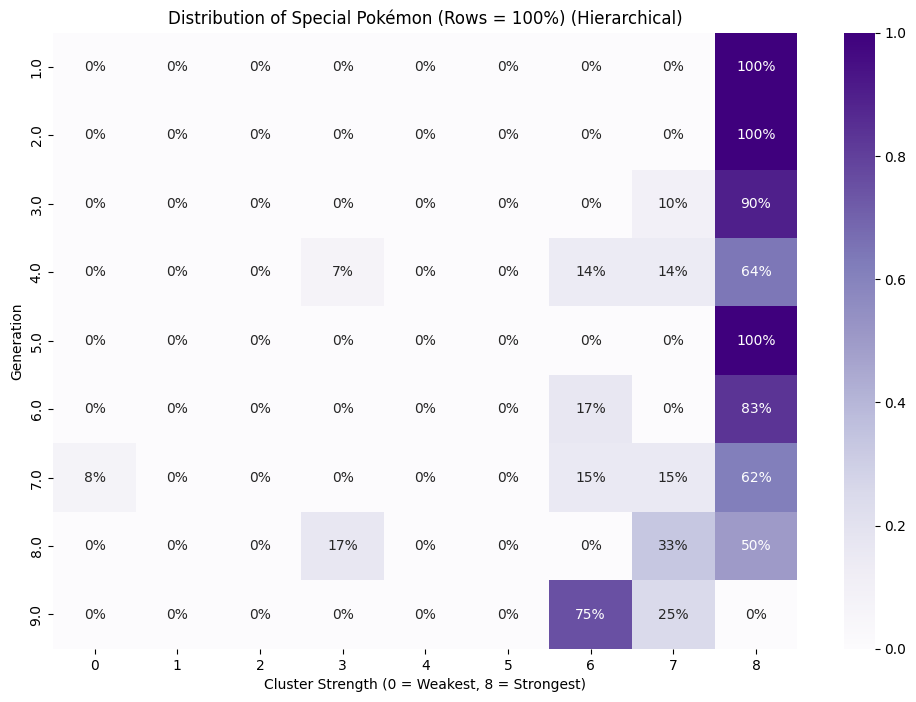


Total count of special Pokémon per generation included in plot:
gen
1.0     5
2.0     6
3.0    10
4.0    14
5.0    13
6.0     6
7.0    26
8.0     6
9.0     4
dtype: int64


In [379]:
plot_special_pokemon_heatmap(d_hc, cluster_col='cluster_hc_ordered', title_suffix='(Hierarchical)')

### **4.6 Saving it to CSV**

In [ ]:
d_hc.to_csv('data_clean_hierarchical_clusters.csv', index=False)


File data_clean_hierarchical_clusters saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **5. Comparison**

### **5.1 Functions**

In [381]:
def get_order_mapping(df, cluster_col, stats):
    summary = df.groupby(cluster_col)[stats].mean()
    summary['total_avg'] = summary.sum(axis=1)
    summary = summary.sort_values('total_avg')
    return {old: new for new, old in enumerate(summary.index)}

In [382]:
def align_clusters_by_strength(df, cluster_col_name, new_col_name):
    # Calculate average stats per cluster
    summary = df.groupby(cluster_col_name)[stat_cols].mean()
    summary['total_avg'] = summary.sum(axis=1)
    summary = summary.sort_values('total_avg')

    # Create mapping: 0 = Weakest, N = Strongest
    mapping = {old: new for new, old in enumerate(summary.index)}

    # Apply mapping
    df[new_col_name] = df[cluster_col_name].map(mapping)
    return df

### **5.2 Data loading and validation**

In [383]:
try:
    df_km = pd.read_csv('data_clean_clusters.csv')
    df_hc = pd.read_csv('data_clean_hierarchical_clusters.csv')
    df_gmm = pd.read_csv('data_clean_clusters_gmm.csv')
    print("All files loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading files: {e}")
    raise

All files loaded successfully.


In [384]:
df_km = align_clusters_by_strength(df_km, 'cluster', 'cluster_km_ordered')

hc_col = 'cluster_hc' if 'cluster_hc' in df_hc.columns else 'cluster'
df_hc = align_clusters_by_strength(df_hc, hc_col, 'cluster_hc_ordered')

df_gmm = align_clusters_by_strength(df_gmm, 'cluster', 'cluster_gmm_ordered')

print("Clusters re-ordered by strength for K-Means, HC, and GMM.")

Clusters re-ordered by strength for K-Means, HC, and GMM.


In [385]:
if 'cluster' not in df_km.columns:
    raise ValueError("Column 'cluster' not found in K-Means CSV.")

if 'cluster_hc_ordered' not in df_hc.columns:
    if 'cluster_hc' in df_hc.columns:
        print("Ordered HC column not found. Creating it now...")
    else:
        raise ValueError("Column 'cluster_hc_ordered' not found in Hierarchical CSV.")

In [ ]:
stat_cols = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']

km_summary = df_km.groupby('cluster')[stat_cols].mean()
km_summary['total_avg'] = km_summary.sum(axis=1)
km_summary = km_summary.sort_values('total_avg')

km_mapping = {old: new for new, old in enumerate(km_summary.index)}
df_km['cluster_km_ordered'] = df_km['cluster'].map(km_mapping)

print("K-Means clusters re-ordered by strength for fair comparison.")

gmm_summary = df_gmm.groupby('cluster')[stat_cols].mean()
gmm_summary['total_avg'] = gmm_summary.sum(axis=1)
gmm_summary = gmm_summary.sort_values('total_avg')

gmm_mapping = {old: new for new, old in enumerate(gmm_summary.index)}
df_gmm['cluster_gmm_ordered'] = df_gmm['cluster'].map(gmm_mapping)


K-Means clusters re-ordered by strength for fair comparison.

--- Cluster Count Check ---
K-Means clusters: 9
Hierarchical clusters: 9
Success: Both methods used the same number of clusters.


### **5.3 Initializing DataFrame**

In [387]:
comparison = pd.DataFrame({
    'K-Means (Ordered)': df_km['cluster_km_ordered'],
    'Hierarchical (Ordered)': df_hc['cluster_hc_ordered']
})

comparison2 = pd.DataFrame({
    'EM GMM (Ordered)': df_gmm['cluster_gmm_ordered'],
    'Hierarchical (Ordered)': df_hc['cluster_hc_ordered']
})

comparison3 = pd.DataFrame({
    'K-Means (Ordered)': df_km['cluster_km_ordered'],
    'EM GMM (Ordered)': df_gmm['cluster_gmm_ordered']
})

### **5.4 Comparison Matrix**
This matrix visualizes the absolute consistency between the K-Means and Hierarchical clustering algorithms. Both axes represent the clusters ordered by strength (0 = Weakest, 8 = Strongest).


* **Interpretation:**
    * **Diagonal:** High numbers along the diagonal indicate that both algorithms assigned the same Pokémon to equivalent strength tiers.
    * **Off-Diagonal:** Non-zero numbers off the diagonal reveal disagreements, where one algorithm considers a Pokémon to be in a stronger or weaker category than the other.
    * **The Number:** Represents the exact count of Pokémon found in the intersection of a specific K-Means cluster and a Hierarchical cluster.

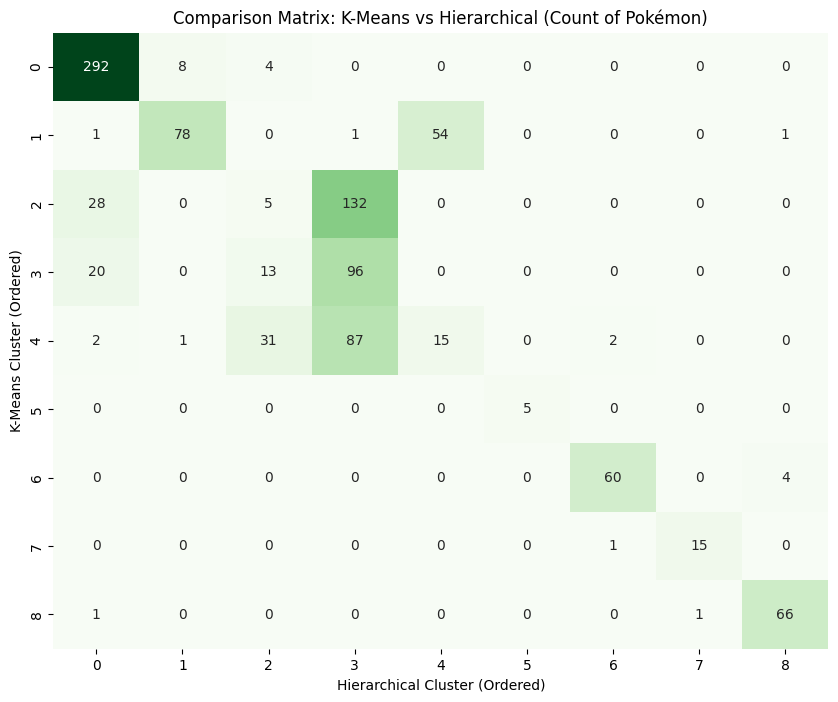

In [388]:
plt.figure(figsize=(10, 8))
conf_matrix = pd.crosstab(comparison['K-Means (Ordered)'], comparison['Hierarchical (Ordered)'])
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Comparison Matrix: K-Means vs Hierarchical (Count of Pokémon)')
plt.ylabel('K-Means Cluster (Ordered)')
plt.xlabel('Hierarchical Cluster (Ordered)')
plt.show()

33

### **5.5 Consistency Check**

This heatmap illustrates the conditional probability of cluster assignment between the two models.

* **Interpretation:**
    * **High Diagonal Values:** Indicate strong agreement and stability between the two algorithms for those specific clusters.
    * **Distributed Values (Smearing):** If a row's intensity is spread across multiple columns, it suggests that the Hierarchical algorithm splits a single K-Means cluster into smaller sub-groups, indicating a divergence in how the models interpret the data structure.

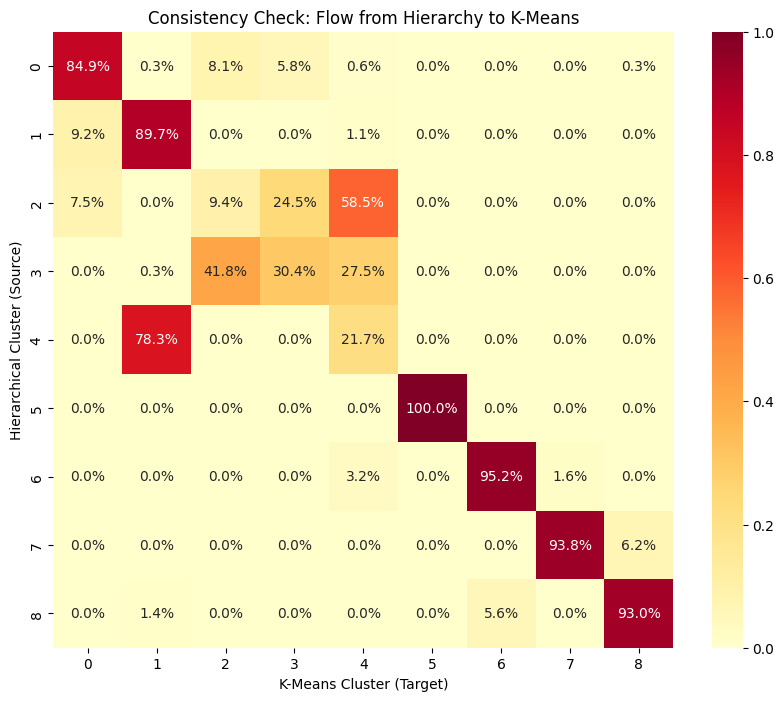

In [389]:
plt.figure(figsize=(10, 8))
conf_matrix_norm = pd.crosstab(
    comparison['Hierarchical (Ordered)'],
    comparison['K-Means (Ordered)'],
    normalize='index'
)
sns.heatmap(conf_matrix_norm, annot=True, fmt='.1%', cmap='YlOrRd')
plt.title('Consistency Check: Flow from Hierarchy to K-Means')
plt.xlabel('K-Means Cluster (Target)')
plt.ylabel('Hierarchical Cluster (Source)')
plt.show()

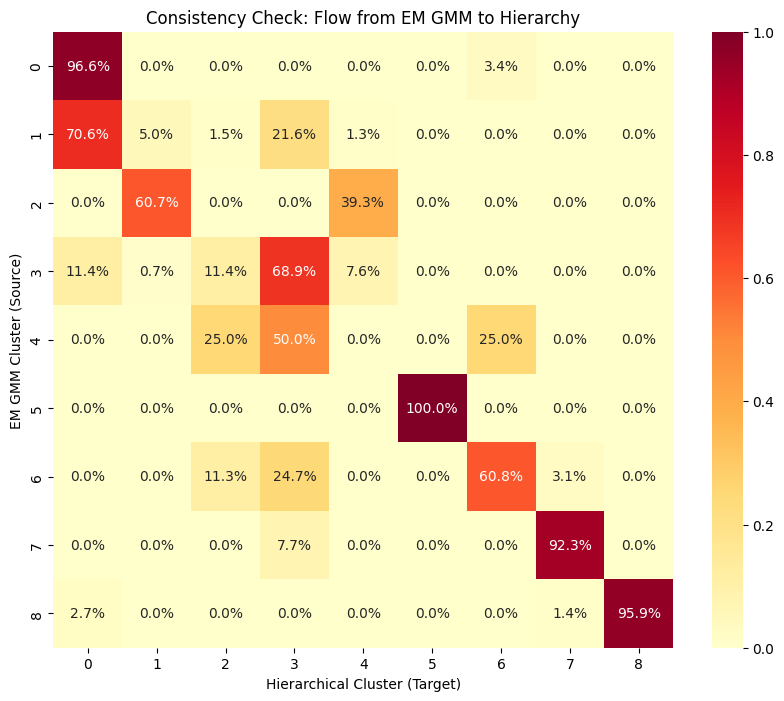

In [390]:
plt.figure(figsize=(10, 8))
conf_matrix_norm = pd.crosstab(
    comparison2['EM GMM (Ordered)'],
    comparison2['Hierarchical (Ordered)'],
    normalize='index'
)
sns.heatmap(conf_matrix_norm, annot=True, fmt='.1%', cmap='YlOrRd')
plt.title('Consistency Check: Flow from EM GMM to Hierarchy')
plt.ylabel('EM GMM Cluster (Source)')
plt.xlabel('Hierarchical Cluster (Target)')
plt.show()

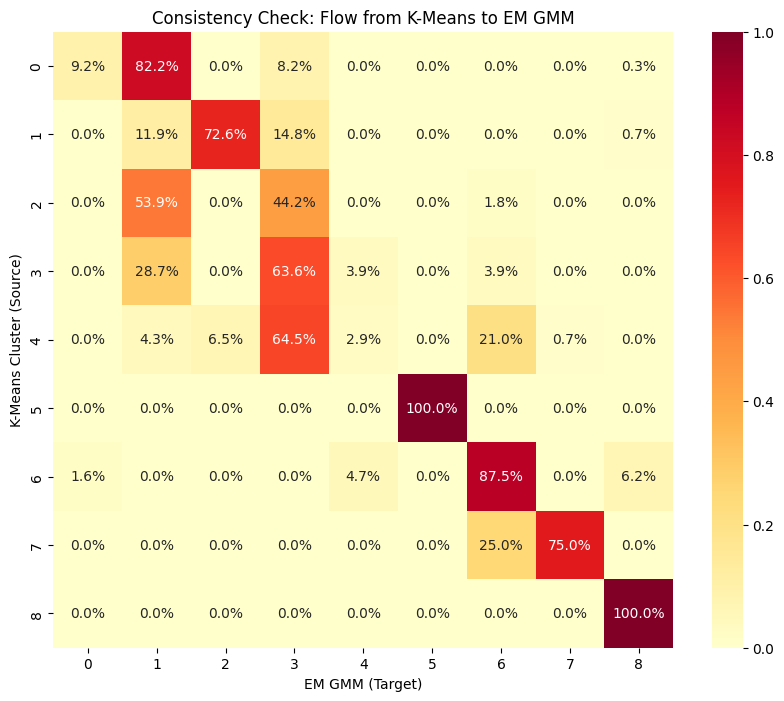

In [391]:
plt.figure(figsize=(10, 8))
conf_matrix_norm = pd.crosstab(
    comparison3['K-Means (Ordered)'],
    comparison3['EM GMM (Ordered)'],
    normalize='index'
)
sns.heatmap(conf_matrix_norm, annot=True, fmt='.1%', cmap='YlOrRd')
plt.title('Consistency Check: Flow from K-Means to EM GMM')
plt.ylabel('K-Means Cluster (Source)')
plt.xlabel('EM GMM (Target)')
plt.show()

### **5.6 Cluster Size Comparison**

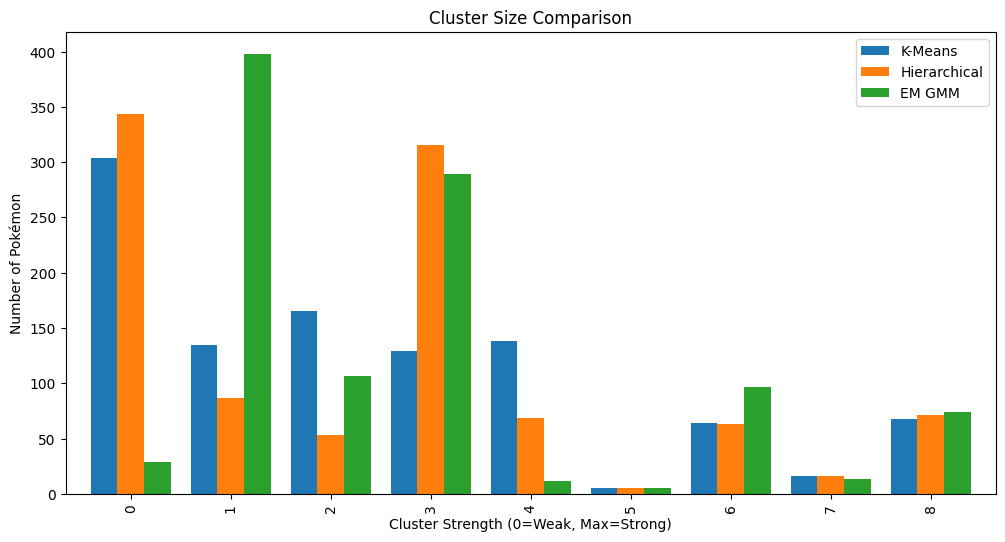

In [392]:
counts_km = comparison['K-Means (Ordered)'].value_counts().sort_index()
counts_hc = comparison['Hierarchical (Ordered)'].value_counts().sort_index()
counts_gmm = comparison2['EM GMM (Ordered)'].value_counts().sort_index()

size_df = pd.DataFrame({'K-Means': counts_km, 'Hierarchical': counts_hc, 'EM GMM': counts_gmm})

size_df.plot(kind='bar', figsize=(12, 6), width=0.8)
plt.title('Cluster Size Comparison')
plt.xlabel('Cluster Strength (0=Weak, Max=Strong)')
plt.ylabel('Number of Pokémon')
plt.legend()
plt.show()

### **5.6 Suspicious Cluster 5**
Heavy boys but not so powerful


In [393]:
merged_all = df_km[['english_name', 'cluster_km_ordered']].merge(
    df_hc[['english_name', 'cluster_hc_ordered']], on='english_name', how='inner'
).merge(
    df_gmm[['english_name', 'cluster_gmm_ordered']], on='english_name', how='inner'
)

# 4. Find the "Pure" Cluster 5 Intersection
# Pokémon that are in Cluster 5 across ALL three methods
intersection_triple_5 = merged_all[
    (merged_all['cluster_km_ordered'] == 5) &
    (merged_all['cluster_hc_ordered'] == 5) &
    (merged_all['cluster_gmm_ordered'] == 5)
]

# 5. Print Results
print("-" * 40)
print(f"Total Pokémon in Cluster 5 (Consensus across KM, HC, GMM): {len(intersection_triple_5)}")
print("-" * 40)

if not intersection_triple_5.empty:
    print("Here are 5 examples of these Pokémon:")
    print(intersection_triple_5['english_name'].head(5).tolist())
else:
    print("No Pokémon found that are in Cluster 5 for all three methods simultaneously.")

----------------------------------------
Total Pokémon in Cluster 5 (Consensus across KM, HC, GMM): 5
----------------------------------------
Here are 5 examples of these Pokémon:
['Onix', 'Steelix', 'Wailord', 'Eternatus', 'Dondozo']


## **6. Generation per Cluster Distribution**

### **6.1 Function Implementation**

In [427]:
k = 9
stat_cols = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']
clusters_low = [0, 1, 2, 3, 4, 5]
clusters_high = [6, 7, 8]

In [437]:
def analyze_generation_distribution(df, cluster_col, method_name):
    """
    Calculates percentage of Gen 1-6 in Low Clusters and Gen 7-9 in High Clusters.
    """
    print(f"\n>>> ANALYSIS FOR: {method_name} (k={k}) <<<")

    subset_gen1_6 = df[df['gen'].isin(range(1, 7))] # Gens 1-6
    subset_gen7_9 = df[df['gen'].isin(range(7, 10))] # Gens 7-9

    total_gen1_6 = len(subset_gen1_6)
    total_gen7_9 = len(subset_gen7_9)

    # Calculate Percentages
    in_low = subset_gen1_6[subset_gen1_6[cluster_col].isin(clusters_low)]
    pct_low = (len(in_low) / total_gen1_6) * 100 if total_gen1_6 > 0 else 0

    in_high = subset_gen7_9[subset_gen7_9[cluster_col].isin(clusters_high)]
    pct_high = (len(in_high) / total_gen7_9) * 100 if total_gen7_9 > 0 else 0

    # Print Results
    print(f"Generations 1-6 (Total: {total_gen1_6})")
    print(f" -> % in Low/Mid Clusters (0-5): {pct_low:.2f}%")

    print(f"Generations 7-9 (Total: {total_gen7_9})")
    print(f" -> % in High/Strong Clusters (6-8): {pct_high:.2f}%")
    print("-" * 50)

In [438]:
def align_clusters_by_strength(df, cluster_col):
    """
    Sorts clusters based on the average sum of base stats.
    Returns the DataFrame with re-mapped cluster labels (0 = weakest).
    """
    # Calculate average stats per cluster
    cluster_stats = df.groupby(cluster_col)[stat_cols].mean()
    # Sum stats to get "strength" and sort
    strength_order = cluster_stats.sum(axis=1).sort_values().index
    # Create mapping: Old Label -> New Label (0 to k-1)
    mapping = {old: new for new, old in enumerate(strength_order)}

    # Apply mapping
    df[cluster_col] = df[cluster_col].map(mapping)
    return df

In [448]:
def plot_high_tier_comparison(df, cluster_col, title_suffix=""):
    """
    Plots the percentage of Pokémon in the strongest clusters (6-8) for Gen 1-6 vs Gen 7-9.
    """
    plot_df = df.copy()
    plot_df['Gen_Group'] = plot_df['gen'].apply(lambda x: 'Gen 7-9' if x >= 7 else 'Gen 1-6')
    high_clusters = [6, 7, 8]

    group_stats = plot_df.groupby('Gen_Group')[cluster_col].apply(
        lambda x: (x.isin(high_clusters).sum() / len(x)) * 100
    ).reset_index(name='Pct_in_High_Clusters')

    plt.figure(figsize=(8, 6))
    ax = sns.barplot(x='Gen_Group', y='Pct_in_High_Clusters', data=group_stats, palette=['#3498db', '#e74c3c'])
    plt.title(f'Power Creep Indication: Presence in Strongest Clusters (6-8)\n{title_suffix}', fontsize=14)
    plt.ylabel('Percentage of Pokémon in Group (%)')
    plt.xlabel('Generation Group')
    plt.ylim(0, 100)

    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')
    plt.show()

In [449]:
def plot_cluster_distribution(df, cluster_col, title_suffix=""):
    """
    Plots the full distribution of generations across all strength clusters.
    """
    plot_df = df.copy()
    plot_df['Gen_Group'] = plot_df['gen'].apply(lambda x: 'Gen 7-9' if x >= 7 else 'Gen 1-6')

    dist_data = plot_df.groupby(['Gen_Group', cluster_col]).size().reset_index(name='Count')
    group_totals = plot_df.groupby('Gen_Group').size()
    dist_data['Percentage'] = dist_data.apply(lambda row: (row['Count'] / group_totals[row['Gen_Group']]) * 100, axis=1)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=cluster_col, y='Percentage', hue='Gen_Group', data=dist_data, palette=['#3498db', '#e74c3c'])

    plt.title(f'Distribution of Generations Across Strength Clusters (0=Weakest, 8=Strongest)\n{title_suffix}', fontsize=14)
    plt.xlabel('Cluster ID (Sorted by Strength)')
    plt.ylabel('Percentage of Generation Group (%)')
    plt.legend(title='Generation Group')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

In [455]:
def plot_power_creep_side_by_side(df, cluster_col, title_suffix=""):
    """
    Plots both Power Creep visualizations side-by-side.
    (Updated to fix Seaborn FutureWarning)
    """
    plot_df = df.copy()
    plot_df['Gen_Group'] = plot_df['gen'].apply(lambda x: 'Gen 7-9' if x >= 7 else 'Gen 1-6')
    high_clusters = [6, 7, 8]

    group_stats = plot_df.groupby('Gen_Group')[cluster_col].apply(
        lambda x: (x.isin(high_clusters).sum() / len(x)) * 100
    ).reset_index(name='Pct_in_High_Clusters')

    dist_data = plot_df.groupby(['Gen_Group', cluster_col]).size().reset_index(name='Count')
    group_totals = plot_df.groupby('Gen_Group').size()
    dist_data['Percentage'] = dist_data.apply(lambda row: (row['Count'] / group_totals[row['Gen_Group']]) * 100, axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(20, 7))

    sns.barplot(
        x='Gen_Group',
        y='Pct_in_High_Clusters',
        hue='Gen_Group',
        data=group_stats,
        palette=['#3498db', '#e74c3c'],
        legend=False,
        ax=axes[0]
    )

    axes[0].set_title(f'Ratio in Strongest Clusters (6-8)\n{title_suffix}', fontsize=14)
    axes[0].set_ylabel('Percentage (%)')
    axes[0].set_xlabel('')
    axes[0].set_ylim(0, 100)

    for p in axes[0].patches:
        if pd.notnull(p.get_height()):
             axes[0].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold', fontsize=12)

    sns.barplot(
        x=cluster_col,
        y='Percentage',
        hue='Gen_Group',
        data=dist_data,
        palette=['#3498db', '#e74c3c'],
        ax=axes[1]
    )

    axes[1].set_title(f'Full Distribution Across Clusters (0-8)\n{title_suffix}', fontsize=14)
    axes[1].set_xlabel('Cluster ID (Sorted by Strength)')
    axes[1].set_ylabel('Percentage within Group (%)')
    axes[1].legend(title='Generation Group')
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

### **6.2 Running K-means and GMM with k=9**

In [422]:
print("Running K-Means...")
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
d_km_9 = d.copy()
d_km_9['cluster'] = kmeans.fit_predict(d_scaled)

# Sort by strength
d_km_9 = align_clusters_by_strength(d_km_9, 'cluster')

Running K-Means...


In [423]:
print("Running GMM...")
gmm = GaussianMixture(n_components=k, random_state=42)
d_gmm_9 = d.copy()
d_gmm_9['cluster'] = gmm.fit_predict(d_scaled)

# Sort by strength
d_gmm_9 = align_clusters_by_strength(d_gmm_9, 'cluster')

Running GMM...


### **6.3 K-Means**

In [444]:
clusters_0_5 = [0, 1, 2, 3, 4, 5]
clusters_6_8 = [6, 7, 8]

In [445]:
if 'd_with_clusters' in locals():
    analyze_generation_distribution(d_km_9, 'cluster', 'K-Means')
else:
    print("DataFrame 'd_with_clusters' not found. Please run the K-Means section first.\n")


>>> ANALYSIS FOR: K-Means (k=9) <<<
Generations 1-6 (Total: 721)
 -> % in Low/Mid Clusters (0-5): 89.60%
Generations 7-9 (Total: 303)
 -> % in High/Strong Clusters (6-8): 25.41%
--------------------------------------------------


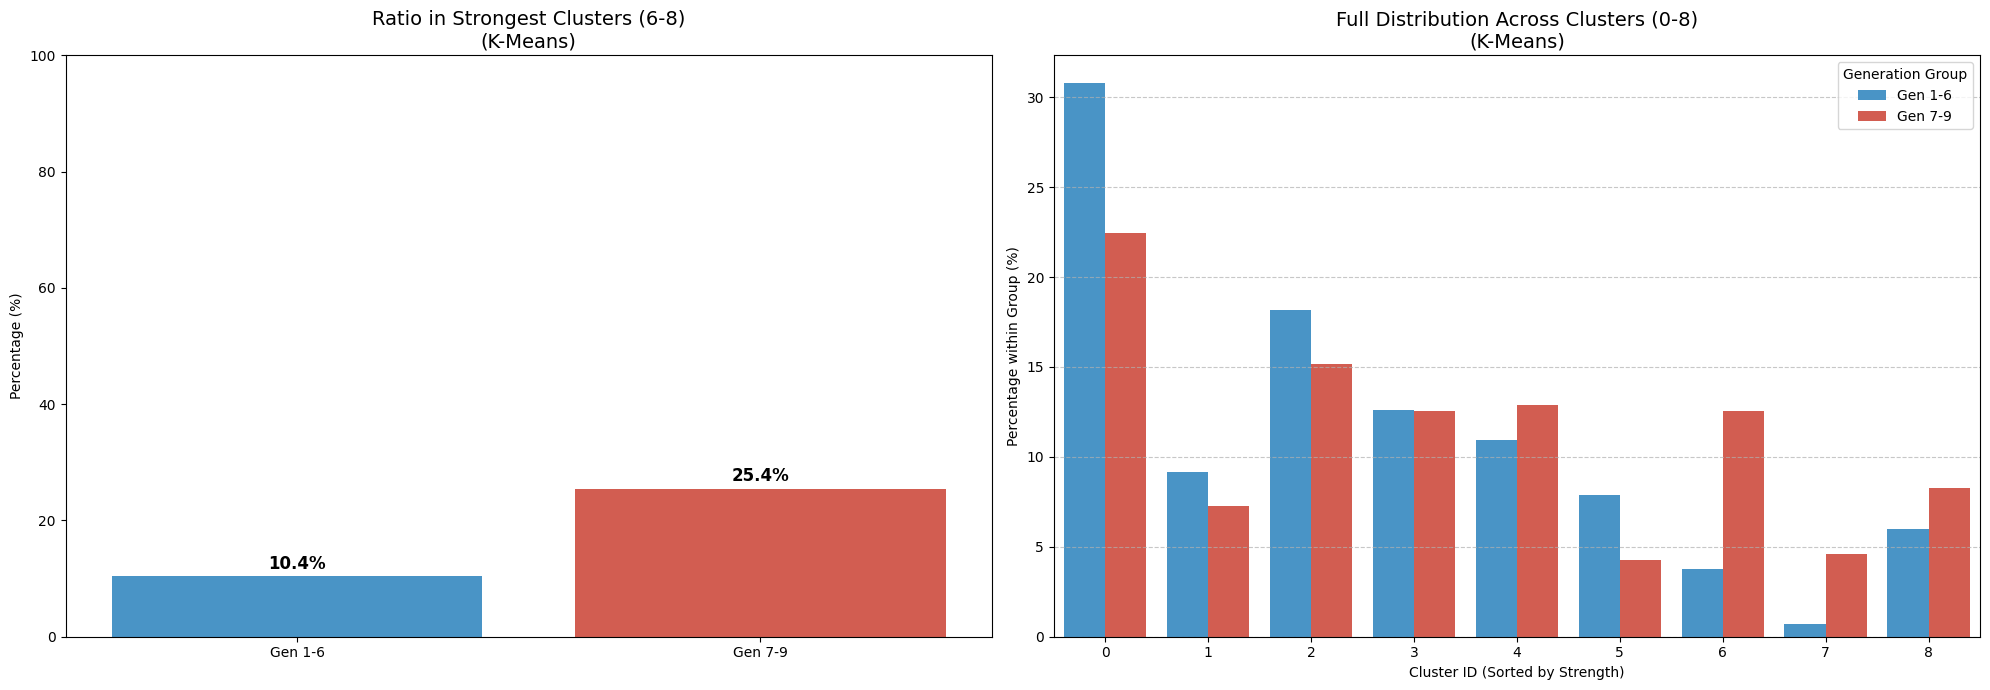

In [456]:
if 'd_km_9' in locals():
    plot_power_creep_side_by_side(d_km_9, 'cluster', title_suffix="(K-Means)")

### **6.4 Hiearchical**

In [440]:
if 'd_hc' in locals():
    analyze_generation_distribution(d_hc, 'cluster_hc', 'Hierarchical Clustering')
else:
    print("DataFrame 'd_hc' not found. Please run the Hierarchical Clustering section first.\n")


>>> ANALYSIS FOR: Hierarchical Clustering (k=9) <<<
Generations 1-6 (Total: 721)
 -> % in Low/Mid Clusters (0-5): 82.39%
Generations 7-9 (Total: 303)
 -> % in High/Strong Clusters (6-8): 14.85%
--------------------------------------------------


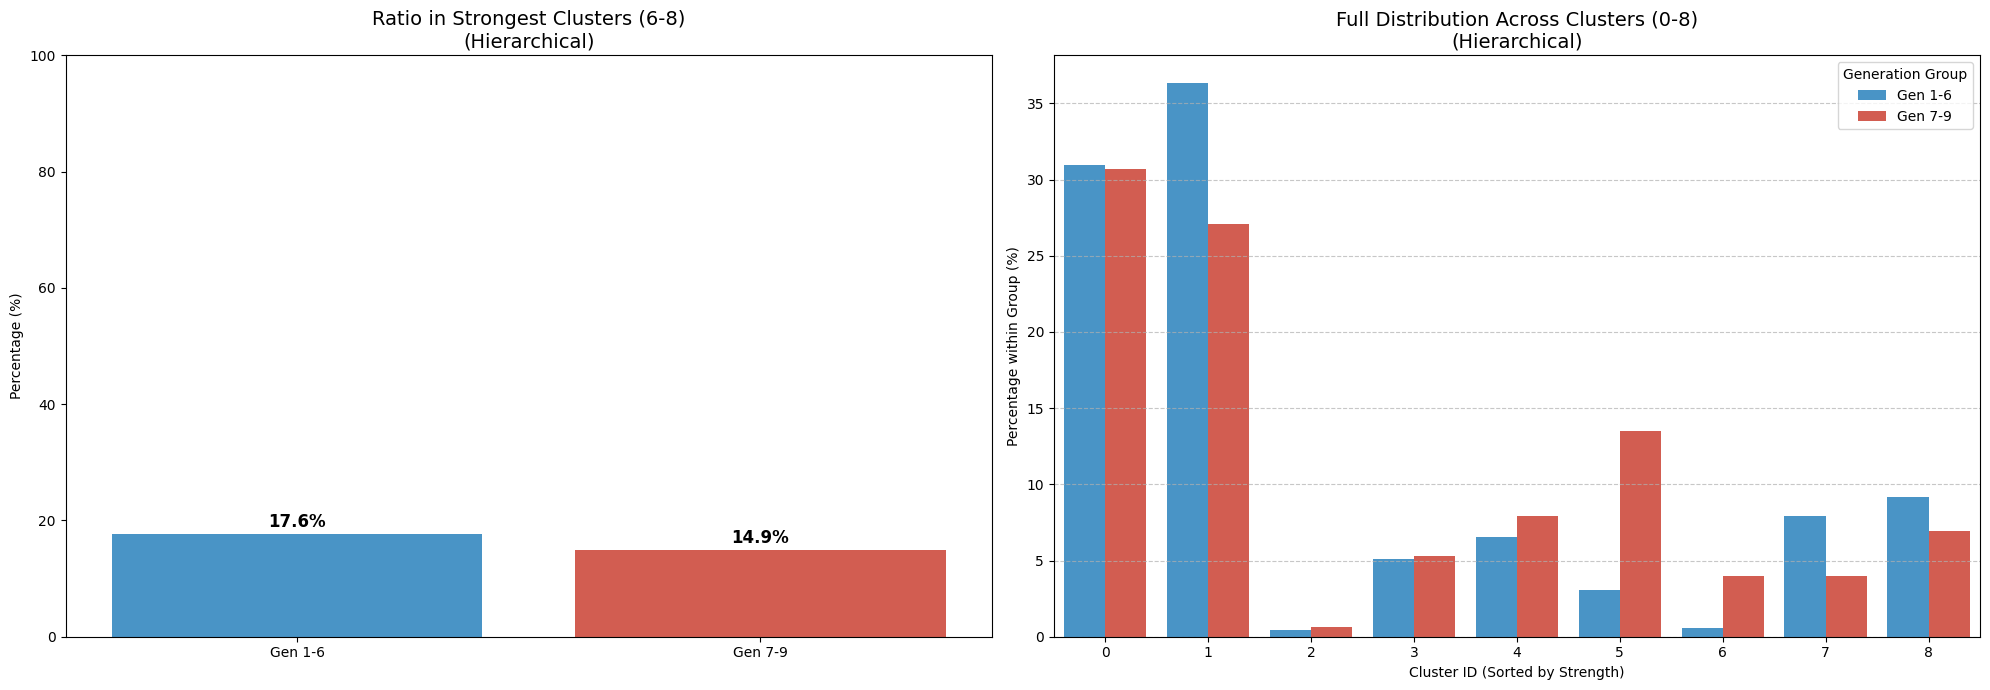

In [457]:
plot_power_creep_side_by_side(d_hc, 'cluster_hc', title_suffix="(Hierarchical)")

### **6.5 GMM**

In [441]:
if 'd_with_clusters_gmm_optimal' in locals():
    analyze_generation_distribution(d_gmm_9, 'cluster', 'Gaussian Mixture Models (GMM)')
else:
    print("DataFrame 'd_with_clusters_gmm_optimal' not found. Please run the GMM section first.\n")


>>> ANALYSIS FOR: Gaussian Mixture Models (GMM) (k=9) <<<
Generations 1-6 (Total: 721)
 -> % in Low/Mid Clusters (0-5): 86.55%
Generations 7-9 (Total: 303)
 -> % in High/Strong Clusters (6-8): 28.71%
--------------------------------------------------


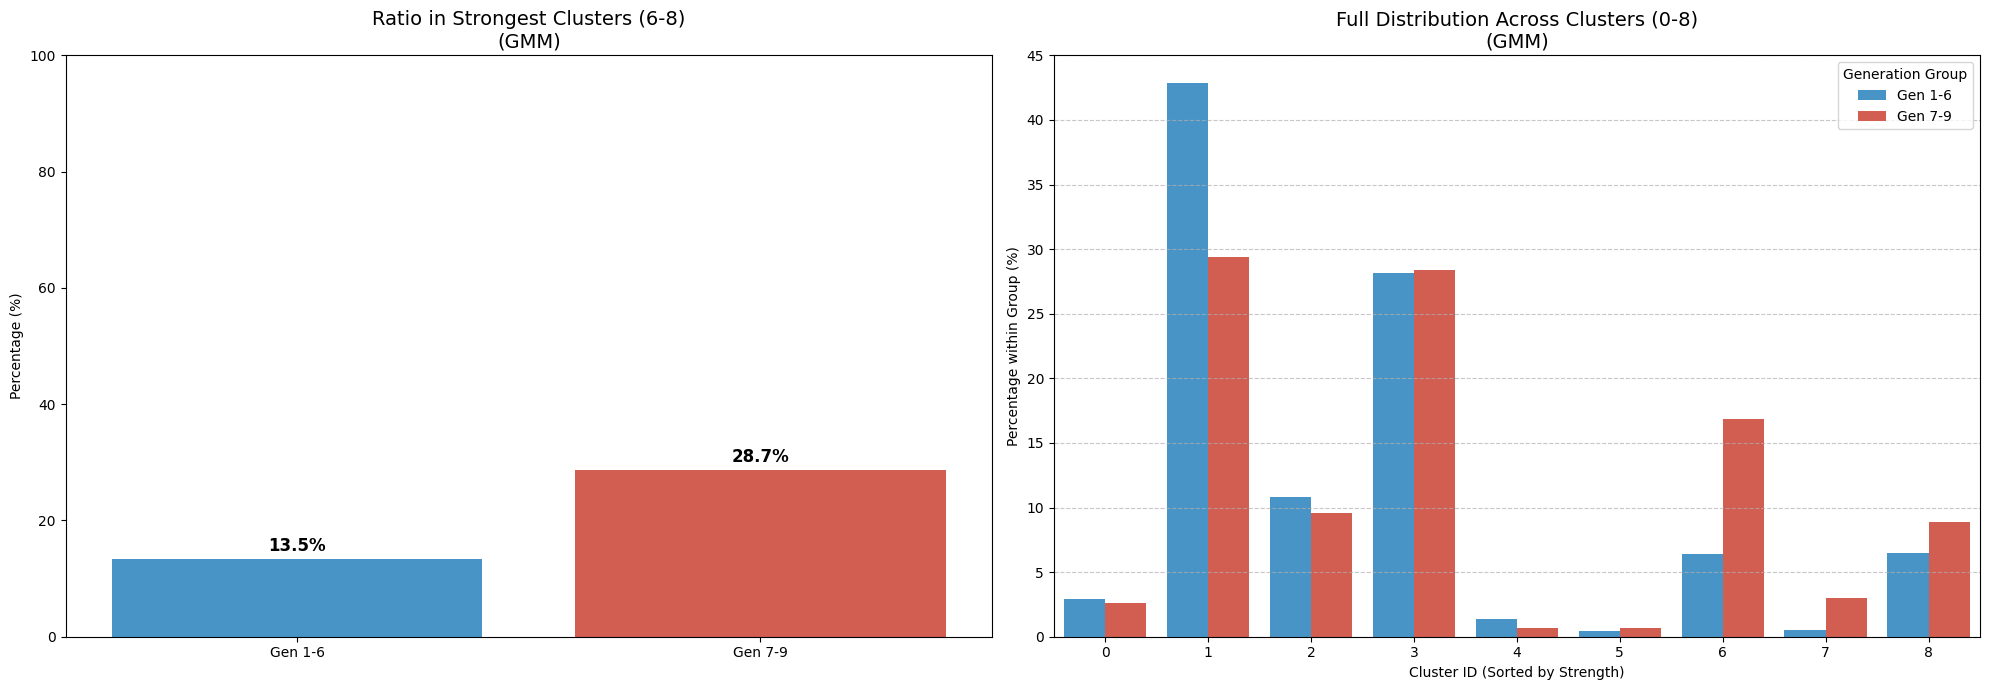

In [458]:
if 'd_gmm_9' in locals():
    plot_power_creep_side_by_side(d_gmm_9, 'cluster', title_suffix="(GMM)")